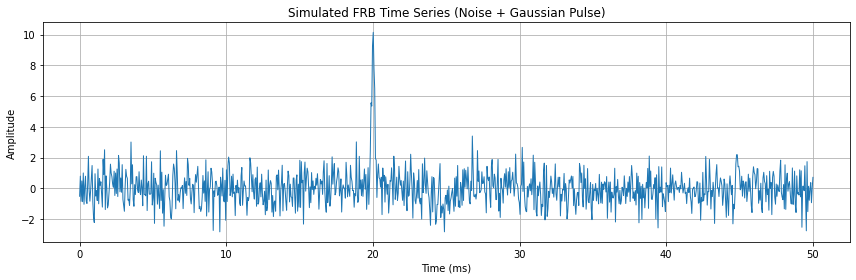

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 50, 1000) 

noise = np.random.normal(0, 1, size=t.size)

# FRB-like pulse: Gaussian peak
pulse_center = 20      # ms
pulse_width = 0.1      # ms
pulse_amplitude = 10   # Jy (arbitrary)

pulse = pulse_amplitude * np.exp(-(t - pulse_center)**2 / (2 * pulse_width**2))

# Combined signal
signal = noise + pulse

# Plot
plt.figure(figsize=(12,4))
plt.plot(t, signal, linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Simulated FRB Time Series (Noise + Gaussian Pulse)")
plt.tight_layout()
plt.grid()
plt.show()


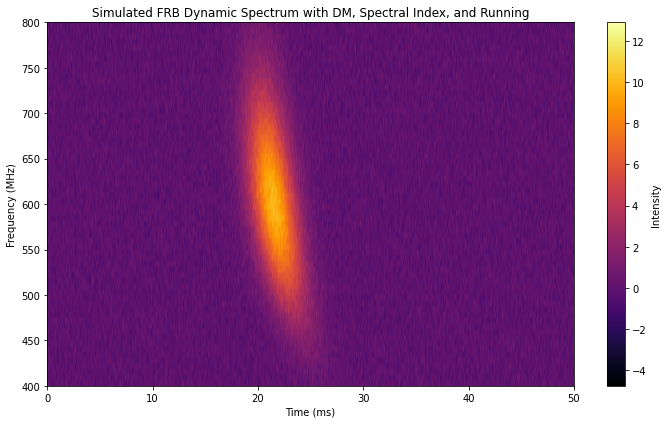

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Time and frequency axes
# -----------------------------
t = np.linspace(0, 50, 5000)          # ms
freqs = np.linspace(400, 800, 64)     # MHz

dynamic_spectrum = np.zeros((len(freqs), len(t)))

# -----------------------------
# 2. White noise
# -----------------------------
noise_level = 1.0
noise = np.random.normal(0, noise_level, size=dynamic_spectrum.shape)

# -----------------------------
# 3. FRB pulse in time (Gaussian)
# -----------------------------
pulse_width = 1.5      # ms
pulse_amplitude = 10   # arbitrary units

# -----------------------------
# 4. Dispersion Measure (DM)
# -----------------------------
DM = 300000  # pc/cm^3 (example)
nu_ref = freqs.max()  # reference frequency for zero delay

# Dispersion delay formula
delay_ms = 4.15 * DM * (freqs**-2 - nu_ref**-2)

# -----------------------------
# 5. Spectral index γ
# -----------------------------
gamma = 0
spec_index_shape = (freqs / freqs.mean()) ** gamma

# -----------------------------
# 6. Spectral running r
# -----------------------------
r = -0.04
gamma0 = gamma
gamma_freq = gamma0 + r * (freqs - freqs.mean())
spec_running_shape = (freqs / freqs.mean()) ** gamma_freq

# -----------------------------
# 7. Build dynamic spectrum
# -----------------------------
for i, f in enumerate(freqs):

    # Time-shifted pulse due to dispersion
    pulse_center = 20 + delay_ms[i]  # ms
    pulse_time = pulse_amplitude * np.exp(-(t - pulse_center)**2 / (2 * pulse_width**2))

    # Apply spectral shape
    spectrum_factor = spec_running_shape[i]

    dynamic_spectrum[i] = noise[i] + pulse_time * spectrum_factor

# -----------------------------
# 8. Plot the dynamic spectrum
# -----------------------------
plt.figure(figsize=(10, 6))
plt.imshow(dynamic_spectrum, aspect='auto', origin='lower',
           extent=[t.min(), t.max(), freqs.min(), freqs.max()],
           cmap='inferno')

plt.colorbar(label="Intensity")
plt.xlabel("Time (ms)")
plt.ylabel("Frequency (MHz)")
plt.title("Simulated FRB Dynamic Spectrum with DM, Spectral Index, and Running")
plt.tight_layout()
plt.show()


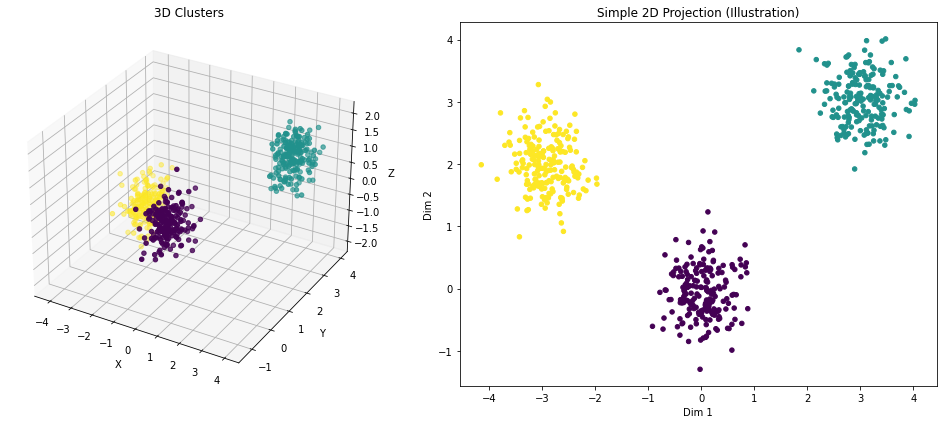

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 1. Create synthetic 3D clusters
# -----------------------------
np.random.seed(42)

cluster1 = np.random.normal(loc=[0, 0, 0], scale=0.4, size=(200, 3))
cluster2 = np.random.normal(loc=[3, 3, 1], scale=0.4, size=(200, 3))
cluster3 = np.random.normal(loc=[-3, 2, -1], scale=0.4, size=(200, 3))

X = np.vstack([cluster1, cluster2, cluster3])
labels = np.array([0]*200 + [1]*200 + [2]*200)

# -----------------------------
# 2. Plot the 3D clusters
# -----------------------------
fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=labels, cmap='viridis', s=20)

ax.set_title("3D Clusters")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# -----------------------------
# 3. Simple 2D projection (no UMAP)
# -----------------------------
# Option A: take first two coordinates
X_2d = X[:, :2]

# -----------------------------
# 4. Plot the 2D projection
# -----------------------------
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap='viridis', s=20)

ax2.set_title("Simple 2D Projection (Illustration)")
ax2.set_xlabel("Dim 1")
ax2.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()
